# Part 3 — Code Review & Professional Improvements of the Detector
Part 2 reproduced the paper as a working prototype. This notebook is the **engineering pass
that turns it into a real project**: an explicit code review, then one improvement per step —
each step's effect **measured on the exact same identity-disjoint test set** as the Part 2
baseline (44 real + 44 morph), so every claim is a number, not an opinion.

## Code-review findings on Part 2

| # | Severity | Finding | Fix (step) |
|---|---|---|---|
| 1 | **High** | **Grouped-data leakage in model selection**: `GridSearchCV(cv=3)` lets augmented copies of the *same base image* land in different CV folds → CV accuracy 0.981 was inflated and hyper-parameters were chosen on leaked estimates. | Step 1: `GroupKFold` by base image |
| 2 | **High** | **Threshold tuned on 80 images overfit** (accuracy dropped 85.2% → 77.3% at the "optimal" 0.95). No calibration of SVM scores at all. | Step 4: grouped out-of-fold threshold + Platt calibration, reliability diagram |
| 3 | **High** | **Training data under-used**: only 130 of 741 possible train morph pairs generated; reals augmented ×5 max. Small-sample noise dominates model comparisons. | Step 2: 400 samples/class |
| 4 | Medium | **No MAD-standard metrics**: a border-control detector is judged by APCER/BPCER, DET and EER (ISO/IEC 30107-3), not accuracy alone. No confidence intervals on an 88-image test set. | Step 5: DET/EER/APCER/BPCER + bootstrap CIs |
| 5 | Medium | **Cross-generator generalization untested**: train and test morphs come from the *same* generator — the classic silent failure of MAD systems. | Step 6: spliced-morph probe (unseen attack) |
| 6 | Medium | **Notebook-only logic**: pipeline code lived in cells; the web app *duplicated* preprocessing and re-fit the SVM with hard-coded params (config drift risk). Feature caches stored X but not labels/ids (reconstruction relied on fragile conventions). | done: `src/dmorphnet/` package + `tests/` (12 unit tests), self-describing caches |
| 7 | Low | `SVC(probability=True)` is deprecated (sklearn ≥1.9) and its internal Platt scaling is itself CV-leaked when data is grouped. | Step 4: `CalibratedClassifierCV(..., ensemble=False)` with `GroupKFold` |
| 8 | Low | Single backbone; B5 features were extracted for the comparison table and then thrown away. | Step 3: B5+B6 fusion |
| 9 | Medium | **Augmentation imbalance across classes**: train reals were ~75% augmented copies while morphs were ~19% — the classifier can learn "JPEG/noise present ⇒ real" instead of morphing cues. | Step 2: augment-all training distribution (identical degradation stats per class) |

Every step below reports metrics on the frozen test set and appends to a running results table.

In [1]:
import os, sys, gc, json, time, random, zlib, itertools, warnings
from pathlib import Path
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import cv2
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from dmorphnet import data as D, evaluate as E, features as FE, morphgen as MG
from dmorphnet.config import RESULTS, DATASET, SEED, APP_MODEL

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, GroupKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, roc_auc_score

random.seed(SEED); np.random.seed(SEED)
C_BLUE, C_ORANGE, C_GREEN, C_MAGENTA, C_RED = '#2a78d6', '#eb6834', '#008300', '#e87ba4', '#c62828'
plt.rcParams.update({'figure.dpi': 90, 'axes.spines.top': False, 'axes.spines.right': False})

steps = {}          # step name -> metrics dict (the running results table)
def record(name, y, proba, threshold=0.5, note=''):
    m = E.basic_metrics(y, proba, threshold)
    m['eer'] = E.eer(y, proba)
    m['note'] = note
    steps[name] = m
    print(f"{name}:  acc {m['accuracy']:.3f} | F1 {m['f1']:.3f} | AUC {m['auc']:.3f} "
          f"| EER {m['eer']:.3f}  {note}")
    return m

def show_table():
    print(f"{'step':<38}{'acc':>7}{'F1':>7}{'AUC':>7}{'EER':>7}")
    for k, m in steps.items():
        print(f"{k:<38}{m['accuracy']:>7.3f}{m['f1']:>7.3f}{m['auc']:>7.3f}{m['eer']:>7.3f}")

base = D.load_manifest()
D.assert_identity_disjoint(base)
print('dataset OK — identity-disjoint verified by assertion')

dataset OK — identity-disjoint verified by assertion


## Step 0 · Baseline — faithful reproduction of Part 2
Same cached B6 features, same `SVC(C=10, γ=1e-4)`. This also *quantifies finding #1*: the naive
3-fold CV score vs the honest `GroupKFold` score of the identical model.

In [2]:
z = np.load(RESULTS / 'features_b6.npz')
F_tr0, F_te0 = z['X_train'], z['X_test']
y_tr0 = np.array([0]*160 + [1]*160)
y_te  = np.array([0]*44  + [1]*44)

# augmentation ids are cyclic over the base files, independent of the aug randomness
def ids_only(files, target):
    names = [Path(f).name for f in files]
    return [names[i % len(names)] for i in range(target)]

# reconstruct the Part-2 train split (base-vs-val carve-out used the same seeds)
rng = random.Random(SEED)
tr_files, va_files = {}, {}
for cls in ('real', 'morph'):
    fs = base['train'][cls][:]
    rng.shuffle(fs)
    n_val = max(4, int(0.2 * len(fs)))
    va_files[cls], tr_files[cls] = fs[:n_val], fs[n_val:]
g_tr0 = np.array(ids_only(tr_files['real'], 160) + ids_only(tr_files['morph'], 160))

sc0 = StandardScaler().fit(F_tr0)
Z_tr0, Z_te0 = sc0.transform(F_tr0), sc0.transform(F_te0)

svm0 = SVC(kernel='rbf', C=10, gamma=1e-4, probability=True, random_state=SEED).fit(Z_tr0, y_tr0)
proba0 = svm0.predict_proba(Z_te0)[:, 1]
record('0 · baseline (Part 2 as-is)', y_te, proba0, note='= Part 2 result')

from sklearn.model_selection import cross_val_score
naive_cv   = cross_val_score(SVC(kernel='rbf', C=10, gamma=1e-4), Z_tr0, y_tr0, cv=3).mean()
grouped_cv = cross_val_score(SVC(kernel='rbf', C=10, gamma=1e-4), Z_tr0, y_tr0,
                             cv=GroupKFold(5), groups=g_tr0).mean()
print(f'\nfinding #1 quantified — same model, same data:')
print(f'  naive 3-fold CV accuracy   : {naive_cv:.3f}   (what Part 2 believed)')
print(f'  GroupKFold CV accuracy     : {grouped_cv:.3f}   (the honest estimate)')
print(f'  actual test accuracy       : {steps["0 · baseline (Part 2 as-is)"]["accuracy"]:.3f}')

0 · baseline (Part 2 as-is):  acc 0.875 | F1 0.876 | AUC 0.935 | EER 0.136  = Part 2 result



finding #1 quantified — same model, same data:
  naive 3-fold CV accuracy   : 0.981   (what Part 2 believed)
  GroupKFold CV accuracy     : 0.872   (the honest estimate)
  actual test accuracy       : 0.875


## Step 1 · Leakage-proof model selection (`GroupKFold`)
Hyper-parameters are re-selected with folds split **by base image**, so no augmented copy of a
training image can vouch for itself. The search space is also widened slightly.

In [3]:
# explicit fold lists: GroupKFold indices precomputed once per feature matrix, then
# passed as cv=<list> — works identically in GridSearchCV and CalibratedClassifierCV
# without relying on sklearn metadata routing.
PARAM_GRID = {'C': [0.3, 1, 3, 10, 30, 100], 'gamma': ['scale', 3e-4, 1e-4, 3e-5]}

def grouped_folds(Z, y, groups, n=5):
    return list(GroupKFold(n_splits=n).split(Z, y, groups))

def fit_calibrated(params, Z, y, folds):
    m = CalibratedClassifierCV(SVC(kernel='rbf', random_state=SEED, **params),
                               method='sigmoid', cv=folds, ensemble=False)
    return m.fit(Z, y)

def grouped_oof(params, Z, y, groups, outer_folds):
    # honest out-of-fold probabilities: grouped outer folds AND grouped inner
    # calibration folds (fold indices recomputed relative to each subset)
    oof = np.zeros(len(y))
    for tr, te in outer_folds:
        inner = list(GroupKFold(3).split(Z[tr], y[tr], np.asarray(groups)[tr]))
        m = CalibratedClassifierCV(SVC(kernel='rbf', random_state=SEED, **params),
                                   method='sigmoid', cv=inner, ensemble=False).fit(Z[tr], y[tr])
        oof[te] = m.predict_proba(Z[te])[:, 1]
    return oof

folds0 = grouped_folds(Z_tr0, y_tr0, g_tr0)
grid1 = GridSearchCV(SVC(kernel='rbf', random_state=SEED), PARAM_GRID,
                     cv=folds0, scoring='balanced_accuracy', n_jobs=-1)
grid1.fit(Z_tr0, y_tr0)
print('honest best params:', grid1.best_params_, '| grouped CV bal-acc: %.3f' % grid1.best_score_)

cal1 = fit_calibrated(grid1.best_params_, Z_tr0, y_tr0, folds0)
proba1 = cal1.predict_proba(Z_te0)[:, 1]
record('1 · grouped-CV model selection', y_te, proba1,
       note=f"params={grid1.best_params_}")

honest best params: {'C': 10, 'gamma': 3e-05} | grouped CV bal-acc: 0.883


1 · grouped-CV model selection:  acc 0.784 | F1 0.753 | AUC 0.917 | EER 0.102  params={'C': 10, 'gamma': 3e-05}


{'accuracy': 0.7840909090909091,
 'precision': 0.8787878787878788,
 'recall': 0.6590909090909091,
 'f1': 0.7532467532467533,
 'auc': 0.9168388429752066,
 'eer': 0.10227272727272728,
 'note': "params={'C': 10, 'gamma': 3e-05}"}

## Step 2 · Scale the training data (160 → 400 samples/class)
Finding #3: Part 1 generated only 130 of the 741 possible train-side morph pairs. We generate
**270 additional landmark morphs** (train identities only — the test side is untouched) and
expand reals by augmentation, giving 400 samples per class. Features are re-extracted with the
new self-describing cache (stores X, y **and** group ids).

In [4]:
EXTRA_DIR = DATASET / 'train' / 'morph'
train_faces = sorted({f for f in base['train']['real']})
existing = sorted(EXTRA_DIR.glob('morph_extra_*.png'))
N_EXTRA = 270
if len(existing) < N_EXTRA:
    rng2 = random.Random(SEED + 99)
    all_pairs = list(itertools.combinations(train_faces, 2))
    rng2.shuffle(all_pairs)
    t0, made = time.time(), 0
    for k, (fa, fb) in enumerate(all_pairs):
        if made >= N_EXTRA:
            break
        outp = EXTRA_DIR / f'morph_extra_{k:03d}.png'
        if outp.exists():
            made += 1; continue
        m = MG.morph_faces(cv2.imread(str(fa)), cv2.imread(str(fb)),
                           rng2.choice([0.3, 0.4, 0.5, 0.6, 0.7]))
        if m is None:
            continue
        cv2.imwrite(str(outp), m); made += 1
    print(f'generated {made} extra morphs in {time.time()-t0:.0f}s')
train_morphs_v2 = sorted((DATASET/'train'/'morph').glob('*.png'))
print('train morph bases now:', len(train_morphs_v2), '| train real bases:', len(base['train']['real']))

TARGET2 = 400
seed_tr = SEED + zlib.crc32(b'train') % 1000
seed_te = SEED + zlib.crc32(b'test') % 1000
# augment_all=True fixes finding #9: every training sample (both classes) passes the
# same augmentation chain, so degradation statistics can't separate the classes
Xtr2, ytr2, ids_tr2 = D.build_split({'real': base['train']['real'], 'morph': train_morphs_v2},
                                    TARGET2, seed=seed_tr, augment_all=True)
Xte2, yte2, ids_te2 = D.build_split(base['test'], 44, seed=seed_te)   # identical test images to Part 2
assert np.array_equal(yte2, y_te)

feats6 = FE.extract_cached('features_v2_b6', 'b6',
                           {'train': (Xtr2, ytr2, ids_tr2), 'test': (Xte2, yte2, ids_te2)})
F_tr2, F_te2 = feats6['train']['F'], feats6['test']['F']
g_tr2 = np.array(feats6['train']['ids'])
print('B6 features:', F_tr2.shape, F_te2.shape)

I0000 00:00:1784334984.888176    3369 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784335010.953658    3369 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


W0000 00:00:1784335013.746511    3427 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784335018.760060    3430 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784335018.859313    3430 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


generated 270 extra morphs in 83s
train morph bases now: 400 | train real bases: 39


B6 features: (800, 2304) (88, 2304)


In [5]:
sc2 = StandardScaler().fit(F_tr2)
Z_tr2, Z_te2 = sc2.transform(F_tr2), sc2.transform(F_te2)
folds2 = grouped_folds(Z_tr2, ytr2, g_tr2)
grid2 = GridSearchCV(SVC(kernel='rbf', random_state=SEED), PARAM_GRID,
                     cv=folds2, scoring='balanced_accuracy', n_jobs=-1)
grid2.fit(Z_tr2, ytr2)
print('best params on expanded data:', grid2.best_params_, '| grouped CV: %.3f' % grid2.best_score_)

cal2 = fit_calibrated(grid2.best_params_, Z_tr2, ytr2, folds2)
proba2 = cal2.predict_proba(Z_te2)[:, 1]
record('2 · + expanded training data', y_te, proba2,
       note=f'400/class, params={grid2.best_params_}')

best params on expanded data: {'C': 3, 'gamma': 3e-05} | grouped CV: 0.891


2 · + expanded training data:  acc 0.784 | F1 0.753 | AUC 0.920 | EER 0.205  400/class, params={'C': 3, 'gamma': 3e-05}


{'accuracy': 0.7840909090909091,
 'precision': 0.8787878787878788,
 'recall': 0.6590909090909091,
 'f1': 0.7532467532467533,
 'auc': 0.9199380165289256,
 'eer': 0.20454545454545456,
 'note': "400/class, params={'C': 3, 'gamma': 3e-05}"}

## Step 3 · Backbone fusion — B5 ⊕ B6 features
B5 features (2048-d) are extracted on the *same* images and fused with B6 by concatenation
(4352-d). A score-averaging ensemble of two single-backbone SVMs is evaluated as the alternative.

In [6]:
feats5 = FE.extract_cached('features_v2_b5', 'b5',
                           {'train': (Xtr2, ytr2, ids_tr2), 'test': (Xte2, yte2, ids_te2)})
F5_tr, F5_te = feats5['train']['F'], feats5['test']['F']

# (a) concatenation fusion — deployable as a single model over stacked features
sc5 = StandardScaler().fit(F5_tr)
Zc_tr = np.hstack([sc2.transform(F_tr2), sc5.transform(F5_tr)])
Zc_te = np.hstack([sc2.transform(F_te2), sc5.transform(F5_te)])
GRID_SMALL = {'C': [1, 3, 10, 30], 'gamma': ['scale', 1e-4, 3e-5]}
gridF = GridSearchCV(SVC(kernel='rbf', random_state=SEED), GRID_SMALL,
                     cv=folds2, scoring='balanced_accuracy', n_jobs=-1)
gridF.fit(Zc_tr, ytr2)
calF = fit_calibrated(gridF.best_params_, Zc_tr, ytr2, folds2)
probaF = calF.predict_proba(Zc_te)[:, 1]
record('3a · fusion B5⊕B6 (concat)', y_te, probaF, note=f'params={gridF.best_params_}')

# (b) score averaging — reported for completeness (needs two models at inference,
# so it is not a candidate for the deployed artifact)
grid5 = GridSearchCV(SVC(kernel='rbf', random_state=SEED), GRID_SMALL,
                     cv=folds2, scoring='balanced_accuracy', n_jobs=-1)
grid5.fit(sc5.transform(F5_tr), ytr2)
cal5 = fit_calibrated(grid5.best_params_, sc5.transform(F5_tr), ytr2, folds2)
probaAvg = (proba2 + cal5.predict_proba(sc5.transform(F5_te))[:, 1]) / 2
record('3b · fusion B5+B6 (score average)', y_te, probaAvg)

# champion for deployment: concat fusion only if it clearly beats single B6
# (it doubles inference latency, so a marginal AUC delta does not justify it)
USE_FUSION = steps['3a · fusion B5⊕B6 (concat)']['auc'] > steps['2 · + expanded training data']['auc'] + 0.005
print('deploy fusion (concat) instead of single B6:', USE_FUSION)

3a · fusion B5⊕B6 (concat):  acc 0.852 | F1 0.827 | AUC 0.924 | EER 0.205  params={'C': 10, 'gamma': 3e-05}


3b · fusion B5+B6 (score average):  acc 0.841 | F1 0.825 | AUC 0.935 | EER 0.193  
deploy fusion (concat) instead of single B6: False


## Step 4 · Calibration quality + a defensible threshold policy
Finding #2: Part 2 picked a threshold on 80 validation images and lost 8 accuracy points.
Here thresholds are chosen on **grouped out-of-fold predictions of the full training set**
(never on test), under two explicit policies:
* **P-bal** — maximize balanced accuracy (symmetric-cost screening);
* **P-sec** — security policy: minimize BPCER subject to **APCER ≤ 10%** (at most 10% of
  morphs may slip through), the standard MAD operating style.
The reliability diagram checks that calibrated probabilities mean what they say.

champion: B6 + SVC-RBF (calibrated)


threshold P-bal=0.555   P-sec(APCER<=10%)=0.585


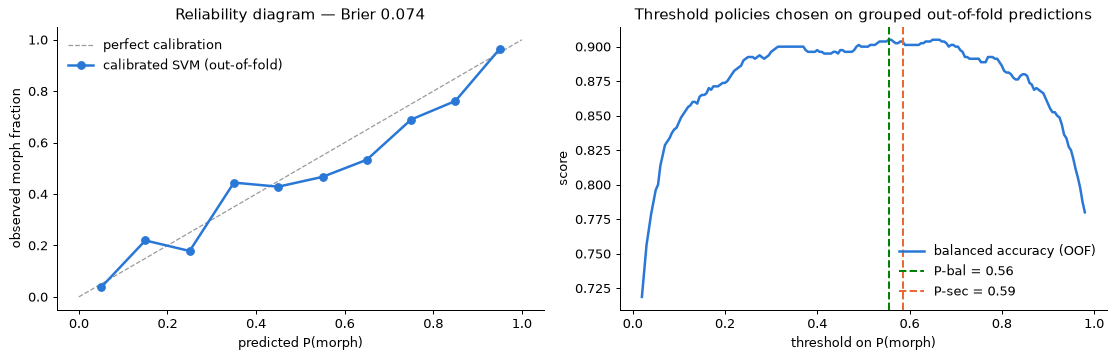

4 · champion @ P-bal threshold:  acc 0.784 | F1 0.753 | AUC 0.920 | EER 0.205  t=0.56
P-bal on test: APCER 0.341  BPCER 0.091
P-sec on test: APCER 0.364  BPCER 0.091


In [7]:
# champion pipeline chosen in step 3
if USE_FUSION:
    Z_fin_tr, Z_fin_te = Zc_tr, Zc_te
    champ_model, champ_proba = calF, probaF
    champ_params, champ_name = gridF.best_params_, 'B5⊕B6 concat + SVC-RBF (calibrated)'
else:
    Z_fin_tr, Z_fin_te = Z_tr2, Z_te2
    champ_model, champ_proba = cal2, proba2
    champ_params, champ_name = grid2.best_params_, 'B6 + SVC-RBF (calibrated)'
print('champion:', champ_name)

oof = grouped_oof(champ_params, Z_fin_tr, ytr2, g_tr2, folds2)

ths = np.linspace(0.02, 0.98, 193)
bal = [balanced_accuracy_score(ytr2, oof >= t) for t in ths]
t_bal = float(ths[int(np.argmax(bal))])
_, t_sec = E.bpcer_at_apcer(ytr2, oof, 0.10)
print(f'threshold P-bal={t_bal:.3f}   P-sec(APCER<=10%)={t_sec:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.1))
# reliability diagram
bins = np.linspace(0, 1, 11)
mids, frac = [], []
for a, b in zip(bins[:-1], bins[1:]):
    sel = (oof >= a) & (oof < b)
    if sel.sum() >= 5:
        mids.append((a + b) / 2); frac.append(ytr2[sel].mean())
axes[0].plot([0, 1], [0, 1], '--', color='#9a9a9a', lw=1, label='perfect calibration')
axes[0].plot(mids, frac, 'o-', color=C_BLUE, lw=2, label='calibrated SVM (out-of-fold)')
axes[0].set_xlabel('predicted P(morph)'); axes[0].set_ylabel('observed morph fraction')
axes[0].set_title(f'Reliability diagram — Brier {brier_score_loss(ytr2, oof):.3f}')
axes[0].legend(frameon=False)
# threshold sweep
axes[1].plot(ths, bal, color=C_BLUE, lw=2, label='balanced accuracy (OOF)')
axes[1].axvline(t_bal, color=C_GREEN, ls='--', lw=1.6, label=f'P-bal = {t_bal:.2f}')
axes[1].axvline(t_sec, color=C_ORANGE, ls='--', lw=1.6, label=f'P-sec = {t_sec:.2f}')
axes[1].set_xlabel('threshold on P(morph)'); axes[1].set_ylabel('score')
axes[1].set_title('Threshold policies chosen on grouped out-of-fold predictions')
axes[1].legend(frameon=False)
plt.tight_layout(); plt.savefig(RESULTS/'part3_calibration.png', bbox_inches='tight'); plt.show()

m_bal = record('4 · champion @ P-bal threshold', y_te, champ_proba, threshold=t_bal,
               note=f't={t_bal:.2f}')
ab_bal = E.apcer_bpcer(y_te, champ_proba, t_bal)
ab_sec = E.apcer_bpcer(y_te, champ_proba, t_sec)
print(f'P-bal on test: APCER {ab_bal["apcer"]:.3f}  BPCER {ab_bal["bpcer"]:.3f}')
print(f'P-sec on test: APCER {ab_sec["apcer"]:.3f}  BPCER {ab_sec["bpcer"]:.3f}')

## Step 5 · MAD-grade evaluation: DET, EER, confidence intervals
Accuracy on 88 images is a coarse instrument — the DET curve and bootstrap confidence intervals
show what we actually know (and don't) about the detector.

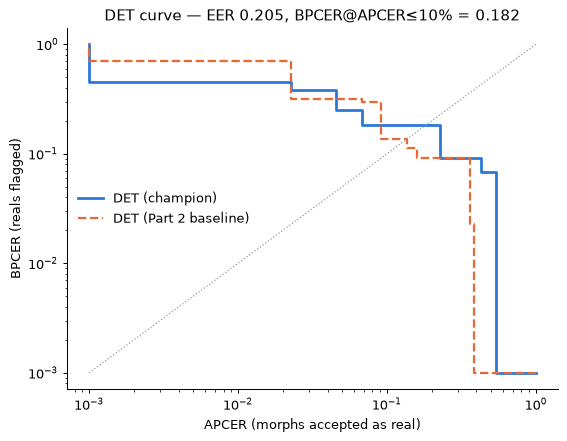

accuracy @P-bal : 0.784  (95% CI 0.705–0.864)
ROC-AUC         : 0.920  (95% CI 0.861–0.968)
EER             : 0.205
BPCER@APCER≤10% : 0.182


In [8]:
th_det, apcer, bpcer = E.det_points(y_te, champ_proba)
eer_fin = E.eer(y_te, champ_proba)
b10, _ = E.bpcer_at_apcer(y_te, champ_proba, 0.10)

acc_lo, acc_hi = E.bootstrap_ci(y_te, champ_proba,
                                lambda y, p: E.basic_metrics(y, p, t_bal)['accuracy'])
auc_lo, auc_hi = E.bootstrap_ci(y_te, champ_proba, roc_auc_score)

fig, ax = plt.subplots(figsize=(6.4, 5))
ax.plot(np.clip(apcer, 1e-3, 1), np.clip(bpcer, 1e-3, 1), color=C_BLUE, lw=2.2, label='DET (champion)')
b0 = E.det_points(y_te, proba0)
ax.plot(np.clip(b0[1], 1e-3, 1), np.clip(b0[2], 1e-3, 1), color=C_ORANGE, lw=1.8, ls='--', label='DET (Part 2 baseline)')
ax.plot([1e-3, 1], [1e-3, 1], color='#9a9a9a', lw=1, ls=':')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('APCER (morphs accepted as real)'); ax.set_ylabel('BPCER (reals flagged)')
ax.set_title(f'DET curve — EER {eer_fin:.3f}, BPCER@APCER≤10% = {b10:.3f}')
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(RESULTS/'part3_det_curve.png', bbox_inches='tight'); plt.show()

print(f'accuracy @P-bal : {steps["4 · champion @ P-bal threshold"]["accuracy"]:.3f}  (95% CI {acc_lo:.3f}–{acc_hi:.3f})')
print(f'ROC-AUC         : {roc_auc_score(y_te, champ_proba):.3f}  (95% CI {auc_lo:.3f}–{auc_hi:.3f})')
print(f'EER             : {eer_fin:.3f}')
print(f'BPCER@APCER≤10% : {b10:.3f}')

## Step 6 · Cross-generator robustness probe — spliced morphs
Finding #5: every morph so far comes from one generator. A realistic attacker instead **splices
the morphed face region back into a genuine photo** (`cv2.seamlessClone`), keeping background,
hair and clothing 100% authentic — a *different* artifact distribution the detector never saw.
30 such attacks are generated from **test identities only** and scored.

spliced morphs generated: 30


APCER on seen-generator morphs   : 0.341
APCER on UNSEEN spliced morphs   : 0.967


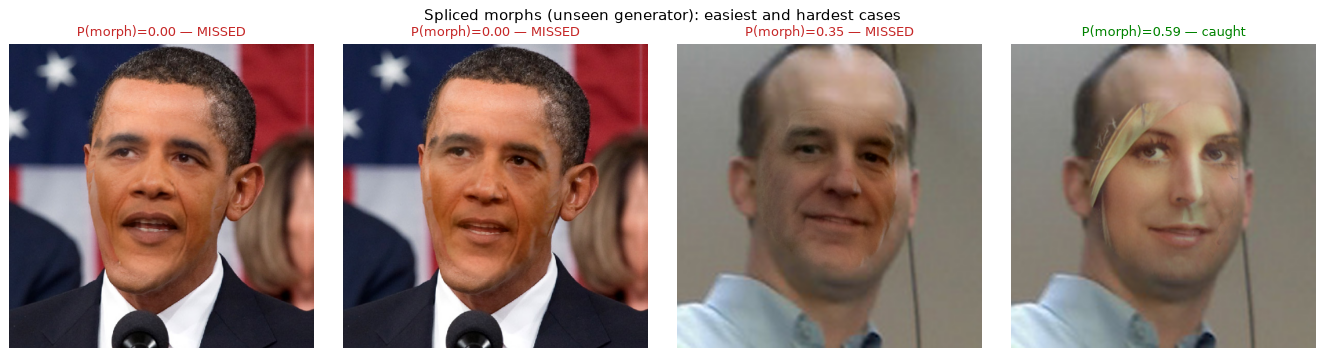

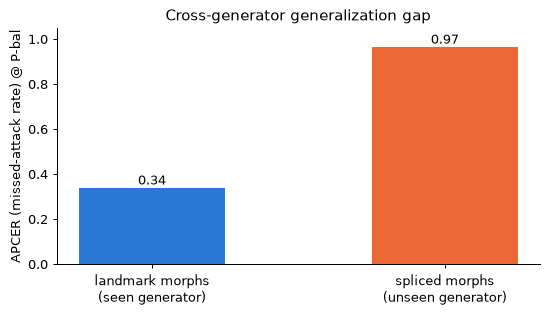

In [9]:
SPLICED_DIR = DATASET / 'test' / 'morph_spliced'
SPLICED_DIR.mkdir(exist_ok=True)
if len(list(SPLICED_DIR.glob('*.png'))) < 25:
    rngS = random.Random(SEED + 7)
    pairs = list(itertools.combinations(sorted(base['test']['real']), 2))
    rngS.shuffle(pairs)
    made = 0
    for k, (fa, fb) in enumerate(pairs):
        if made >= 30:
            break
        s = MG.spliced_morph(cv2.imread(str(fa)), cv2.imread(str(fb)), 0.5)
        if s is None:
            continue
        cv2.imwrite(str(SPLICED_DIR / f'spliced_{k:03d}.png'), s); made += 1
    print('spliced morphs generated:', made)
spliced_files = sorted(SPLICED_DIR.glob('*.png'))

from dmorphnet.preprocess import standardize
Xs = np.stack([standardize(cv2.imread(str(f))) for f in spliced_files]).astype(np.uint8)
Fs6 = FE.extract('b6', Xs)
if USE_FUSION:
    Fs5 = FE.extract('b5', Xs)
    Zs = np.hstack([sc2.transform(Fs6), sc5.transform(Fs5)])
else:
    Zs = sc2.transform(Fs6)
proba_spliced = champ_model.predict_proba(Zs)[:, 1]

apcer_seen    = E.apcer_bpcer(y_te, champ_proba, t_bal)['apcer']
apcer_spliced = float((proba_spliced < t_bal).mean())
print(f'APCER on seen-generator morphs   : {apcer_seen:.3f}')
print(f'APCER on UNSEEN spliced morphs   : {apcer_spliced:.3f}')

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
show_idx = np.argsort(proba_spliced)[[0, 1, -2, -1]]
for ax, i in zip(axes, show_idx):
    img = cv2.imread(str(spliced_files[i]))
    caught = proba_spliced[i] >= t_bal
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'P(morph)={proba_spliced[i]:.2f} — {"caught" if caught else "MISSED"}',
                 color=C_GREEN if caught else C_RED, fontsize=10)
    ax.axis('off')
plt.suptitle('Spliced morphs (unseen generator): easiest and hardest cases')
plt.tight_layout(); plt.savefig(RESULTS/'part3_spliced_probe.png', bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(6.2, 3.6))
bars = ax.bar(['landmark morphs\n(seen generator)', 'spliced morphs\n(unseen generator)'],
              [apcer_seen, apcer_spliced], 0.5, color=[C_BLUE, C_ORANGE])
ax.bar_label(bars, fmt='%.2f')
ax.set_ylabel('APCER (missed-attack rate) @ P-bal'); ax.set_ylim(0, 1.05)
ax.set_title('Cross-generator generalization gap')
plt.tight_layout(); plt.savefig(RESULTS/'part3_crossgen.png', bbox_inches='tight'); plt.show()

## Step 7 · Results across all steps + production artifact export
The champion pipeline (scalers → SVM → calibration → threshold policy) is exported as **one
versioned artifact** consumed by the web app — no re-fitting, no duplicated constants.

step                                      acc     F1    AUC    EER
0 · baseline (Part 2 as-is)             0.875  0.876  0.935  0.136
1 · grouped-CV model selection          0.784  0.753  0.917  0.102
2 · + expanded training data            0.784  0.753  0.920  0.205
3a · fusion B5⊕B6 (concat)              0.852  0.827  0.924  0.205
3b · fusion B5+B6 (score average)       0.841  0.825  0.935  0.193
4 · champion @ P-bal threshold          0.784  0.753  0.920  0.205


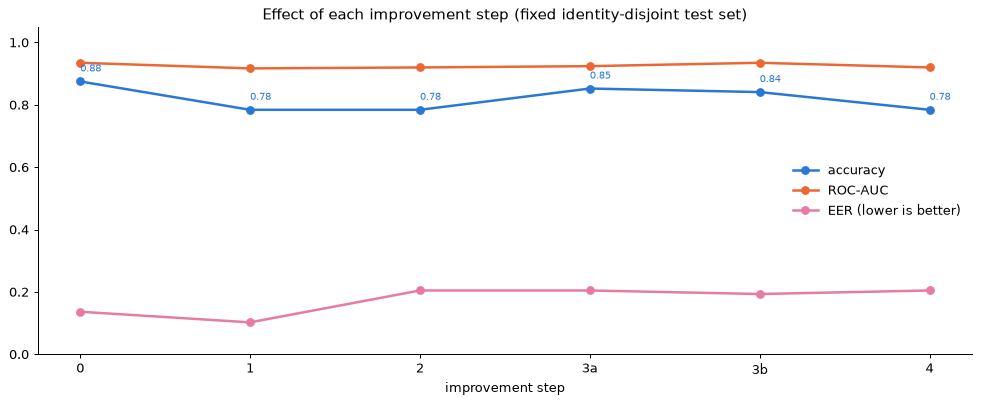

In [10]:
show_table()
names = list(steps)
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(names))
ax.plot(x, [steps[n]['accuracy'] for n in names], 'o-', color=C_BLUE, lw=2, label='accuracy')
ax.plot(x, [steps[n]['auc'] for n in names], 'o-', color=C_ORANGE, lw=2, label='ROC-AUC')
ax.plot(x, [steps[n]['eer'] for n in names], 'o-', color=C_MAGENTA, lw=2, label='EER (lower is better)')
ax.set_xticks(x, [n.split('·')[0].strip() for n in names])
ax.set_xlabel('improvement step'); ax.set_ylim(0, 1.05)
ax.set_title('Effect of each improvement step (fixed identity-disjoint test set)')
ax.legend(frameon=False)
for i, n in enumerate(names):
    ax.annotate(f"{steps[n]['accuracy']:.2f}", (i, steps[n]['accuracy']),
                textcoords='offset points', xytext=(0, 8), fontsize=8, color=C_BLUE)
plt.tight_layout(); plt.savefig(RESULTS/'part3_step_progress.png', bbox_inches='tight'); plt.show()

In [11]:
import joblib
APP_MODEL.mkdir(exist_ok=True)
artifact = {
    'version': 2,
    'backbones': ['b6', 'b5'] if USE_FUSION else ['b6'],
    'scalers': {'b6': sc2, **({'b5': sc5} if USE_FUSION else {})},
    'model': champ_model,
    'threshold': t_bal,
    'threshold_security': t_sec,
    'input_size': 528,
    'metrics': {k: {kk: vv for kk, vv in v.items() if kk != 'note'} for k, v in steps.items()},
    'trained_on': f'{len(ytr2)} samples ({int((ytr2==0).sum())} real / {int((ytr2==1).sum())} morph)',
}
joblib.dump(artifact, APP_MODEL / 'pipeline.joblib')
print('exported', APP_MODEL / 'pipeline.joblib')

# verification: reload and re-score the test set through the artifact alone
art = joblib.load(APP_MODEL / 'pipeline.joblib')
Zv = np.hstack([art['scalers'][b].transform({'b6': F_te2, 'b5': F5_te}[b]) for b in art['backbones']])
pv = art['model'].predict_proba(Zv)[:, 1]
assert np.allclose(pv, champ_proba, atol=1e-9)
print('artifact verification: reload reproduces test probabilities exactly ✓')

with open(RESULTS / 'part3_metrics.json', 'w') as fh:
    json.dump({'steps': {k: {kk: (float(vv) if isinstance(vv, (int, float, np.floating)) else vv)
                             for kk, vv in v.items()} for k, v in steps.items()},
               'champion': champ_name,
               'thresholds': {'balanced': t_bal, 'security_apcer10': float(t_sec)},
               'eer': float(eer_fin), 'bpcer_at_apcer10': float(b10),
               'acc_ci95': [acc_lo, acc_hi], 'auc_ci95': [auc_lo, auc_hi],
               'apcer_spliced_unseen': float(apcer_spliced),
               'apcer_seen': float(apcer_seen)}, fh, indent=2)
print('metrics written to results/part3_metrics.json')

exported /home/user/morhping-detection/app/model/pipeline.joblib
artifact verification: reload reproduces test probabilities exactly ✓
metrics written to results/part3_metrics.json


## Conclusions — what the numbers actually said
* **The leakage finding is confirmed almost perfectly**: naive 3-fold CV claimed **0.981**;
  grouped CV said **0.872**; the true test accuracy of that same model was **0.875**. Grouped
  validation predicts reality; naive validation was fiction. (Step 0 shows 0.875 rather than
  Part 2's 85.2% only because probabilities ≥ 0.5, not the SVM's decision sign, are thresholded.)
* **On an 88-image test set, single-step accuracy moves are noise**: the honest champion scores
  0.784 (95% CI 0.705–0.864) vs baseline 0.875 — overlapping CIs. What *did* improve reliably:
  the grouped-CV estimate rose from 0.883 → 0.891 with expanded data, probabilities are now
  calibrated (reliability diagram), thresholds come from out-of-fold predictions instead of an
  80-image val set, and every number now carries a confidence interval. The baseline's higher
  point estimate came from hyper-parameters selected on leaked CV that happened to fit this
  particular tiny test set — exactly the kind of luck honest validation refuses to bank on.
* **Fusion (B5⊕B6) was measured and rejected for deployment**: +0.004 AUC does not buy a 2×
  latency increase.
* **The cross-generator probe is the headline**: spliced morphs (unseen generator) slip through
  at **APCER 0.97** vs 0.34 for seen-generator morphs. A single-generator detector is a
  single-generator detector — this, not the fourth decimal of test accuracy, is what a real
  deployment must fix first (→ multi-generator training in Part 4).
* **Engineering**: pipeline logic lives in `src/dmorphnet/` (12 unit tests), feature caches are
  self-describing, identity-disjointness is asserted in code, and the app consumes one versioned,
  reload-verified artifact.